# Time Series Split

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")
df = df.rename(columns={"Passengers":"y"})
display(df)

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


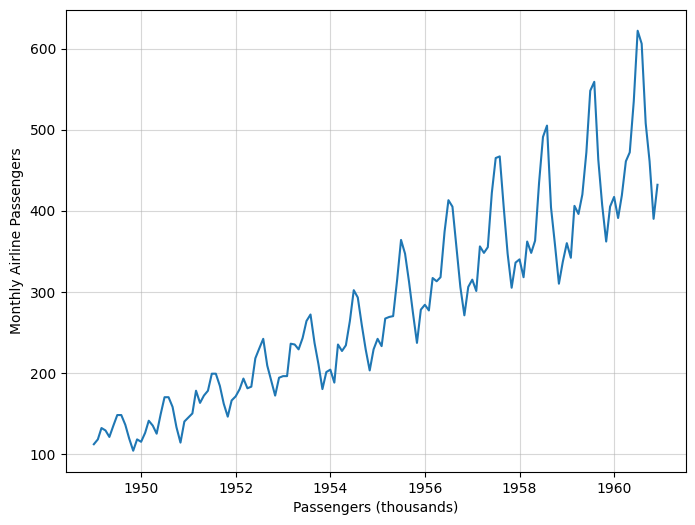

In [3]:
# esplorazione iniziale dei dati
plt.figure(figsize=(8, 6))
plt.plot(df.index, df["y"])
plt.ylabel("Monthly Airline Passengers")
plt.xlabel("Passengers (thousands)")
plt.grid(True, alpha=0.5)
plt.show()

abbiamo due problemi con questi dataset
1. le feature non sono indipendenti né identicamente distribuite
2. le y target non sono continue, però dobbiamo applicare la regressione lineare

per questo andiamo a creare delle colonne in più:
1. colonna che fa la differenza con i passeggeri del mese precedente
2. colonna che calcola numero di passeggeri dello stesso mese ma dell'anno precedente
3. colonna della media degli ultimi 12 mesi

In [4]:
df_features = df.copy()

# 1. mese precedente
df_features["m_prev"] = df_features["y"].shift(1)
# 2. anno precedente
df_features["a_prev"] = df_features["y"].shift(12)
# 3. media annuale
df_features["trend_year"] = df_features["y"].rolling(window=12).mean()

df_features = df_features.dropna().copy()

# suddivisione tra feature e target dopo la sistemazione del db
X = df_features.drop(columns=["y"])
y = df_features["y"].values

display(X)

,m_prev,a_prev,trend_year
Month,,,
1950-01-01,118.0,112.0,126.916667
1950-02-01,115.0,118.0,127.583333
1950-03-01,126.0,132.0,128.333333
1950-04-01,141.0,129.0,128.833333
1950-05-01,135.0,121.0,129.166667
...,...,...,...
1960-08-01,622.0,559.0,463.333333
1960-09-01,606.0,463.0,467.083333
1960-10-01,508.0,407.0,471.583333


In [5]:
K = 10

In [6]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [7]:
acc_standard = []
kf = KFold(n_splits=K, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    acc_standard.append(r2)

In [15]:
acc_ts = []
tscv = TimeSeriesSplit(n_splits=K)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    acc_ts.append(r2)

In [16]:
mean_std = np.mean(acc_standard)
std_kf = np.std(acc_standard)
mean_ts = np.mean(acc_ts)
std_ts = np.std(acc_ts)

print(f"K-Fold Standard:\n\tMedia:\t{mean_std:.4f}\n\tstd:\t{std_kf:.4f}\n\tAccuracy:\t{np.round(acc_standard, 4)}")
print(f"Time Series Split:\n\tMedia:\t{mean_ts:.4f}\n\tstd:\t{std_ts:.4f}\n\tAccuracy:\t{np.round(acc_ts, 4)}")

K-Fold Standard:
	Media:	0.9754
	std:	0.0129
	Accuracy:	[0.9879 0.9924 0.9851 0.9567 0.953  0.9736 0.9628 0.9835 0.9816 0.9769]
Time Series Split:
	Media:	0.4286
	std:	0.3885
	Accuracy:	[-0.5809  0.2307  0.5118  0.6178  0.1675  0.6352  0.6954  0.4991  0.6889
  0.8208]
